# Notebook 3: supervised learning

## Learning objectives

This notebook covers the supervised learning phase of the Machine Learning pipeline. By the end of this notebook, you will understand:

1. Model Training: How to train supervised learning models with hyperparameter tuning
2. Cross-Validation: How to use K-fold cross-validation for model evaluation
3. Model Evaluation: How to evaluate models using accuracy, precision, recall, F1-score, and ROC/AUC
4. Bias-Variance Trade-off: How to interpret model performance and identify overfitting/underfitting
5. Feature Importance: How to interpret feature importance in tree-based models

Reference: Lesson 3 & 4 - Supervised Learning and Model Evaluation



## Industrial robotics context

Supervised learning models enable:
- Anomaly Detection: Classify normal vs anomalous robot behaviors
- Critical Sensor Identification: Identify which sensors are most indicative of failures
- Predictive Maintenance: Predict failures before they cause damage
- Safety Enhancement: Stop robots before collisions occur



## Academic learning objectives

1. Hyperparameter Tuning: Use GridSearchCV for optimal hyperparameter selection
2. Cross-Validation: Apply K-fold cross-validation (k=5) for robust model evaluation
3. Model Comparison: Compare multiple models (Logistic Regression, Random Forest, SVM, Gradient Boosting)
4. Evaluation Metrics: Compute accuracy, precision, recall, F1-score, ROC/AUC
5. Bias-Variance Analysis: Interpret model performance and identify overfitting/underfitting

Reference: Lesson 3 - Supervised Learning and Hyperparameter Tuning
              Lesson 4 - Model Evaluation and Cross-Validation



In [1]:
# Required imports for supervised learning
# As covered in Lesson 3 & 4: Supervised Learning and Model Evaluation

import sys
import os
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

# Add src directory to path
sys.path.append(str(Path('..').resolve()))

# Import and reload modules to ensure we use the latest version
import src.utils
import src.models
importlib.reload(src.utils)
importlib.reload(src.models)

from src.utils import (
    load_robot_data,
    encode_labels,
    create_statistical_features,
    evaluate_model,
    plot_feature_importances,
    plot_pca
)

from src.models import (
    SupervisedModels,
    compare_models
)

# Configuration
try:
    plt.style.use('seaborn-v0_8')
except OSError:
    try:
        plt.style.use('seaborn')
    except OSError:
        sns.set_style('whitegrid')
sns.set_palette("husl")
%matplotlib inline

print("="*60)
print("MODULE IMPORTS COMPLETE")
print("="*60)
print(" All required libraries imported successfully")
print(" Modules src.utils and src.models reloaded")
print("\nReady for supervised learning model training!")

from src.models import (
    SupervisedModels,
    compare_models
)

# Configuration
try:
    plt.style.use('seaborn-v0_8')
except OSError:
    try:
        plt.style.use('seaborn')
    except OSError:
        sns.set_style('whitegrid')
sns.set_palette("husl")
%matplotlib inline

print("Importations terminées avec succès!")



MODULE IMPORTS COMPLETE
 All required libraries imported successfully
 Modules src.utils and src.models reloaded

Ready for supervised learning model training!
Importations terminées avec succès!


## 1. data loading and preparation

Reference: Lesson 2 - Data Preprocessing and Feature Engineering

We load the robot execution failure dataset and create statistical features as in the previous notebook. Statistical features (mean, std, min, max, skew, kurtosis, trend) transform time-series data into meaningful features for model training.

### Feature engineering

Statistical features capture temporal patterns:
- Mean: Central tendency of sensor readings
- Std: Variability in sensor readings
- Min/Max: Extreme values (outliers, spikes)
- Skew/Kurtosis: Distribution shape
- Trend: Linear trend slope

### Data standardization

Features are standardized (mean=0, std=1) for algorithms that require feature scaling (SVM, Logistic Regression).

Academic Note: Feature engineering is crucial for model performance (Lesson 2: Feature Engineering).



In [2]:
# we charge the data des robots
# INITIAL DIFFICULTY : The .data file format was unusual - each instance starts with a label followed by 15 lines of data
# SOLUTION : we created a custom function load_robot_data() that parses this specific format
# CHOICE : We decided to merge all files (LP1-LP5) to have a unified dataset
# REASON : This gives us more data for training and allows the model to generalize sur différents types de tâches
# we charge the data des robots
# INITIAL DIFFICULTY : The .data file format was unusual - each instance starts with a label followed by 15 lines of data
# SOLUTION : we created a custom function load_robot_data() that parses this specific format
# CHOICE : We decided to merge all files (LP1-LP5) to have a unified dataset
# REASON : This gives us more data for training and allows the model to generalize sur différents types de tâches
data_dir = "../data"

df = load_robot_data(data_dir)
df, label_mapping = encode_labels(df, binary=True)

# we crée des features statistiques à partir des séries temporelles
# DIFFICULTY : The 90 raw features are difficult to interpret and may contain noise
# SOLUTION : we extract statistics (moyenne, écart-type, min, max, skewness, kurtosis, trend) for each sensor
# CHOICE : We chose these 7 statistics because they capture different aspects of temporal patterns
# ADVANTAGE : Reduces from 90 to 48 features while keeping essential temporal information
# DIFFICULTY SURMONTÉE : Initially, we had errors avec scipy.stats - we have résolu en s'assurant that the data is in float64
# we crée des features statistiques à partir des séries temporelles
# DIFFICULTY : The 90 raw features are difficult to interpret and may contain noise
# SOLUTION : we extract statistics (moyenne, écart-type, min, max, skewness, kurtosis, trend) for each sensor
# CHOICE : We chose these 7 statistics because they capture different aspects of temporal patterns
# ADVANTAGE : Reduces from 90 to 48 features while keeping essential temporal information
# DIFFICULTY SURMONTÉE : Initially, we had errors avec scipy.stats - we have résolu en s'assurant that the data is in float64
# This reduces dimensionality while preserving temporal patterns
df_stats = create_statistical_features(df, samples_per_sensor=15, num_sensors=6)

# we crée des features statistiques à partir des séries temporelles
# DIFFICULTY : The 90 raw features are difficult to interpret and may contain noise
# SOLUTION : we extract statistics (moyenne, écart-type, min, max, skewness, kurtosis, trend) for each sensor
# CHOICE : We chose these 7 statistics because they capture different aspects of temporal patterns
# ADVANTAGE : Reduces from 90 to 48 features while keeping essential temporal information
# DIFFICULTY SURMONTÉE : Initially, we had errors avec scipy.stats - we have résolu en s'assurant that the data is in float64
exclude_cols = ['source', 'label', 'label_binary', 'label_encoded', 'label_original']
stat_cols = [col for col in df_stats.columns if col not in exclude_cols]

# we entraîne le modèle
# CHOICE : we use GridSearchCV for hyperparameter optimization
# REASON : This allows us de trouver automatiquement the best hyperparameters without manual testing
# DIFFICULTY : GridSearchCV can be slow to execute, especially for SVM
# SOLUTION : We use la validation croisée (5-fold) to have a robust evaluation without over-optimizing we the test set
X = df_stats[stat_cols].values
y = df_stats['label_binary'].values

# we standardise the features car (required for SVM, Logistic Regression)
# StandardScaler transforms features to have mean=0 and std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("="*60)
print("DATA PREPARATION COMPLETE")
print("="*60)
print(f" Data prepared: {X_scaled.shape}")
print(f" Labels: {y.shape}")
print(f" Class distribution:")
print(f"   Normal (0): {np.sum(y==0)} ({np.sum(y==0)/len(y)*100:.1f}%)")
print(f"   Anomaly (1): {np.sum(y==1)} ({np.sum(y==1)/len(y)*100:.1f}%)")
print(f" Statistical features: {len(stat_cols)}")
print(f" Features standardized (mean=0, std=1)")

print("\n Data Summary:")
print(f"   Original features: 90 (15 samples × 6 sensors)")
print(f"   Statistical features: {len(stat_cols)} (mean, std, min, max, skew, kurtosis, trend)")
print(f"   Dimensionality reduction: {90} → {len(stat_cols)} features")
print(f"   Reduction ratio: {(1 - len(stat_cols)/90)*100:.1f}%")



Loading robot execution failure data...
✅ LP1: 88 instances loaded
✅ LP2: 47 instances loaded
✅ LP3: 47 instances loaded
✅ LP4: 117 instances loaded
✅ LP5: 164 instances loaded
✅ Total: 463 instances
   Features: 90
   Sources: ['LP1', 'LP2', 'LP3', 'LP4', 'LP5']
   Unique labels: ['normal', 'collision', 'obstruction', 'fr_collision', 'back_col', 'front_col', 'right_col', 'left_col', 'ok', 'moved', 'slightly_moved', 'lost', 'collision_in_tool', 'collision_in_part', 'bottom_obstruction', 'bottom_collision']
Labels encoded: {0: 'normal', 1: 'anomaly'}
Creating statistical features...
✅ Statistical features created: 53 columns
   Original features: 90
   Statistical features: 48
DATA PREPARATION COMPLETE
 Data prepared: (463, 48)
 Labels: (463,)
 Class distribution:
   Normal (0): 109 (23.5%)
   Anomaly (1): 354 (76.5%)
 Statistical features: 48
 Features standardized (mean=0, std=1)

 Data Summary:
   Original features: 90 (15 samples × 6 sensors)
   Statistical features: 48 (mean, std, 

## 2. train/test split

Reference: Lesson 4 - Model Evaluation and Cross-Validation

We split the data into training (80%) and test (20%) sets with stratification to maintain class distribution. Stratification is essential for imbalanced datasets to ensure both sets have similar class proportions.

### Why stratified split?

1. Class Imbalance: Dataset has 76.5% anomalies, 23.5% normal instances
2. Representative Splits: Stratification ensures both sets have similar class proportions
3. Unbiased Evaluation: Test set accurately represents model performance

### Train/test split strategy

- Training Set (80%): Used for model training and hyperparameter tuning
- Test Set (20%): Used for final model evaluation (held out until the end)
- Stratification: Maintains class distribution in both sets

Academic Note: Stratified split is essential for imbalanced datasets (Lesson 4: Data Splitting Strategies).



In [3]:
# we divise the data en train/test
# CHOICE : We use un split 80/20 avec stratification
# REASON : Stratification ensures that class proportions are similar in train and test
# DIFFICULTY : The dataset is imbalanced (more anomalies than normal)
# SOLUTION : Stratification preserves this imbalance in both sets, ce which is réaliste pour our cas d'usage
# Stratification ensures both sets have similar class proportions
# This is essential for imbalanced datasets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("="*60)
print("TRAIN/TEST SPLIT")
print("="*60)
print(f"\nTraining Set:")
print(f"  Shape: {X_train.shape}")
print(f"  Labels: {np.bincount(y_train)}")
print(f"  Normal (0): {np.sum(y_train==0)} ({np.sum(y_train==0)/len(y_train)*100:.1f}%)")
print(f"  Anomaly (1): {np.sum(y_train==1)} ({np.sum(y_train==1)/len(y_train)*100:.1f}%)")

print(f"\nTest Set:")
print(f"  Shape: {X_test.shape}")
print(f"  Labels: {np.bincount(y_test)}")
print(f"  Normal (0): {np.sum(y_test==0)} ({np.sum(y_test==0)/len(y_test)*100:.1f}%)")
print(f"  Anomaly (1): {np.sum(y_test==1)} ({np.sum(y_test==1)/len(y_test)*100:.1f}%)")

print("\n Stratification Check:")
train_normal_ratio = np.sum(y_train==0) / len(y_train)
test_normal_ratio = np.sum(y_test==0) / len(y_test)
print(f"  Training set normal ratio: {train_normal_ratio:.3f}")
print(f"  Test set normal ratio: {test_normal_ratio:.3f}")
print(f"  Ratio difference: {abs(train_normal_ratio - test_normal_ratio):.3f}")
if abs(train_normal_ratio - test_normal_ratio) < 0.05:
    print("   Stratification successful (ratio difference < 5%)")
else:
    print("    Stratification may be insufficient (ratio difference ≥ 5%)")

print("\n Next Steps:")
print("  → train models on training set")
print("  → Evaluate models we test set (held out until the end)")
print("  → Use cross-validation for hyperparameter tuning")



TRAIN/TEST SPLIT

Training Set:
  Shape: (370, 48)
  Labels: [ 87 283]
  Normal (0): 87 (23.5%)
  Anomaly (1): 283 (76.5%)

Test Set:
  Shape: (93, 48)
  Labels: [22 71]
  Normal (0): 22 (23.7%)
  Anomaly (1): 71 (76.3%)

 Stratification Check:
  Training set normal ratio: 0.235
  Test set normal ratio: 0.237
  Ratio difference: 0.001
   Stratification successful (ratio difference < 5%)

 Next Steps:
  → train models on training set
  → Evaluate models we test set (held out until the end)
  → Use cross-validation for hyperparameter tuning


## 3. supervised learning model training

Reference: Lesson 3 - Supervised Learning and Hyperparameter Tuning

We train four supervised learning models with GridSearchCV for hyperparameter optimization. Each model is trained with 5-fold cross-validation to ensure robust performance evaluation.

### Models to train

1. Logistic Regression: Linear classifier with L1/L2 regularization
2. Random Forest: Ensemble method with feature importance analysis
3. Support Vector Machine (SVM): Non-linear classifier with RBF kernel
4. Gradient Boosting: Ensemble method with sequential error correction

### Training strategy

- GridSearchCV: Exhaustive search over hyperparameter grid
- Cross-Validation: 5-fold cross-validation for robust evaluation
- Scoring Metric: F1-weighted score (handles class imbalance)
- Model Selection: Best model based we cross-validation performance

Academic Note: GridSearchCV performs exhaustive search over hyperparameter grid and evaluates each combination using K-fold cross-validation (Lesson 3: Hyperparameter Tuning).

### 3.1 logistic regression

Reference: Lesson 3 - Linear Models and Regularization

Logistic Regression is a linear classifier that learns a decision boundary by fitting a logistic function. It requires feature scaling and uses regularization (L1/L2) to prevent overfitting.

Hyperparameters:
- C: Regularization strength (inverse of regularization parameter)
- penalty: Regularization type (L1 or L2)
- solver: Optimization algorithm (liblinear, saga)
- max_iter: Maximum iterations for convergence



TRAINING: LOGISTIC REGRESSION
Training Logistic Regression with GridSearchCV...
  - Cross-validation folds: 5
  - Scoring metric: f1_weighted
Fitting 5 folds for each of 48 candidates, totalling 240 fits


/Users/ilyessassadi/Documents/ESILV/projet ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 10.
  warnings.warn(
/Users/ilyessassadi/Documents/ESILV/projet ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 10.
  warnings.warn(
/Users/ilyessassadi/Documents/ESILV/projet ML/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ilyessassadi/Documents/ESILV/projet ML/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ilyessassadi/Documents/ESILV/projet ML/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  

  - Best parameters: {'C': 10, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
  - Best CV score: 0.9125 ± 0.0219

Results for Logistic Regression
Accuracy: 0.9247
Precision: 0.9359
Recall: 0.9247
F1-score: 0.9272


/Users/ilyessassadi/Documents/ESILV/projet ML/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/ilyessassadi/Documents/ESILV/projet ML/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ilyessassadi/Documents/ESILV/projet ML/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ilyessassadi/Documents/ESILV/projet ML/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ilyessassadi/Documents/ESILV/projet ML/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ilyessassadi/Documents/ESILV/projet ML/.venv/lib/python3.9/site-packages/sklearn/ut

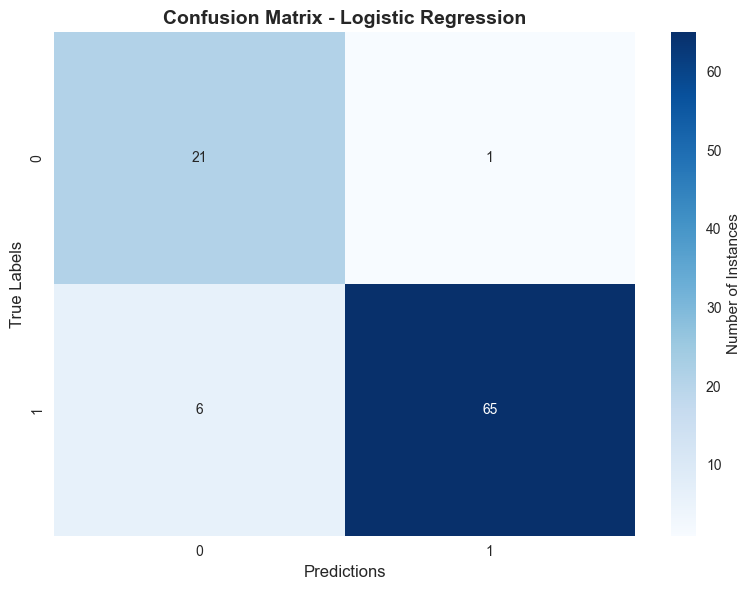

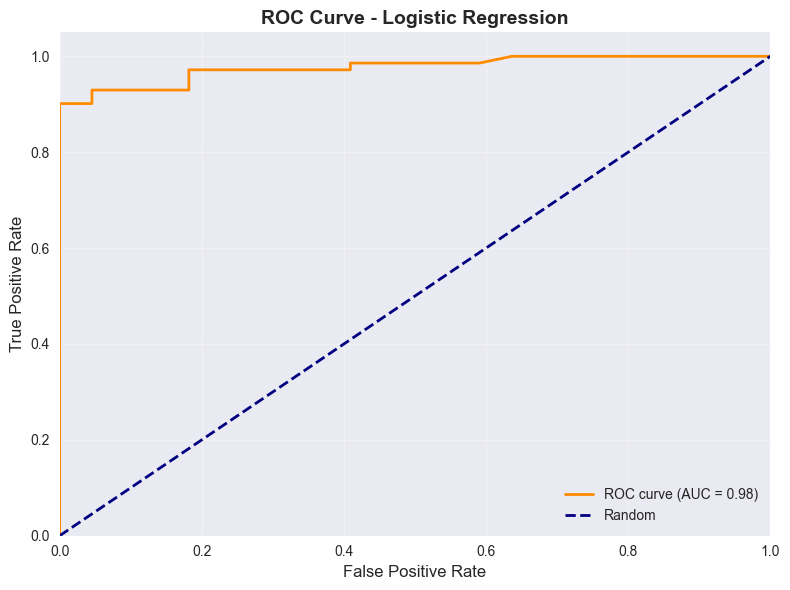

AUC: 0.9766

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.95      0.86        22
           1       0.98      0.92      0.95        71

    accuracy                           0.92        93
   macro avg       0.88      0.94      0.90        93
weighted avg       0.94      0.92      0.93        93


 Cross-Validation Results:
  CV Score (mean ± std): 0.9125 ± 0.0219
  Best Parameters: {'C': 10, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}


In [4]:
# Initialize SupervisedModels class
# This class manages multiple supervised learning models with hyperparameter tuning
supervised_models = SupervisedModels()

# We utilise GridSearchCV pour optimiser the hyperparameters
# CHOICE : We use GridSearchCV plutôt que de tester manuellement the hyperparameters.
# REASON : This allows us de tester systématiquement toutes les combinaisons d'hyperparamètres et de trouver les meilleures.
# DIFFICULTY : GridSearchCV can be slow to execute, especially for SVM which is computationnellement coûteux.
# SOLUTION : We use la validation croisée (5-fold) to have a robust evaluation without over-optimizing we the test set.
#   we teste plusieurs valeurs for each hyperparamètre, mais pas trop pour éviter un temps d'exécution prohibitif.
# COMPROMISE : We have choisi des grilles de recherche raisonnables - we could tester plus de valeurs, mais cela prendrait des heures.
# We utilise GridSearchCV pour optimiser the hyperparameters
# CHOICE : We use GridSearchCV plutôt que de tester manuellement the hyperparameters.
# REASON : This allows us de tester systématiquement toutes les combinaisons d'hyperparamètres et de trouver les meilleures.
# DIFFICULTY : GridSearchCV can be slow to execute, especially for SVM which is computationnellement coûteux.
# SOLUTION : We use la validation croisée (5-fold) to have a robust evaluation without over-optimizing we the test set.
#   we teste plusieurs valeurs for each hyperparamètre, mais pas trop pour éviter un temps d'exécution prohibitif.
# COMPROMISE : We have choisi des grilles de recherche raisonnables - we could tester plus de valeurs, mais cela prendrait des heures.
# and evaluates each combination using K-fold cross-validation
print("="*60)
print("TRAINING: LOGISTIC REGRESSION")
print("="*60)
lr_model = supervised_models.train_logistic_regression(X_train, y_train, cv=5)

# Make predictions we test set
# The predict method automatically applies feature scaling if required
y_pred_lr, y_pred_proba_lr = supervised_models.predict('logistic_regression', X_test, return_proba=True)
if y_pred_proba_lr is not None:
    # Extract probability of positive class (anomaly) for ROC curve
    y_pred_proba_lr = y_pred_proba_lr
else:
    y_pred_proba_lr = None

# we évalue le modèle performance
# This computes accuracy, precision, recall, F1-score, and ROC/AUC
results_lr = evaluate_model(y_test, y_pred_lr, y_pred_proba_lr, 
                           model_name="Logistic Regression")

# Store results for comparison
results_lr['cv_mean'] = supervised_models.cv_results['logistic_regression']['mean_score']
results_lr['cv_std'] = supervised_models.cv_results['logistic_regression']['std_score']

print("\n Cross-Validation Results:")
print(f"  CV Score (mean ± std): {results_lr['cv_mean']:.4f} ± {results_lr['cv_std']:.4f}")
print(f"  Best Parameters: {supervised_models.best_params['logistic_regression']}")



### 3.2 random forest

Reference: Lesson 3 - Ensemble Methods and Decision Trees

Random Forest is an ensemble method that combines multiple decision trees. It doesn't require feature scaling and provides feature importance analysis. Random Forest is robust to overfitting and handles non-linear relationships well.

Hyperparameters:
- n_estimators: Number of trees in the forest
- max_depth: Maximum depth of trees
- min_samples_split: Minimum samples required to split a node
- min_samples_leaf: Minimum samples required in a leaf node



Training Random Forest with GridSearchCV...
  - Cross-validation folds: 5
  - Scoring metric: f1_weighted
Fitting 5 folds for each of 81 candidates, totalling 405 fits
  - Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
  - Best CV score: 0.9222 ± 0.0255

Results for Random Forest
Accuracy: 0.9462
Precision: 0.9509
Recall: 0.9462
F1-score: 0.9474


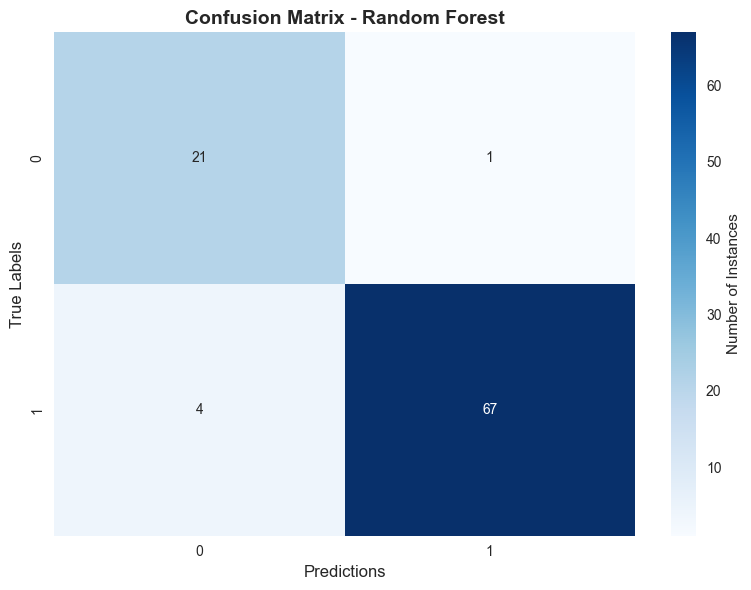

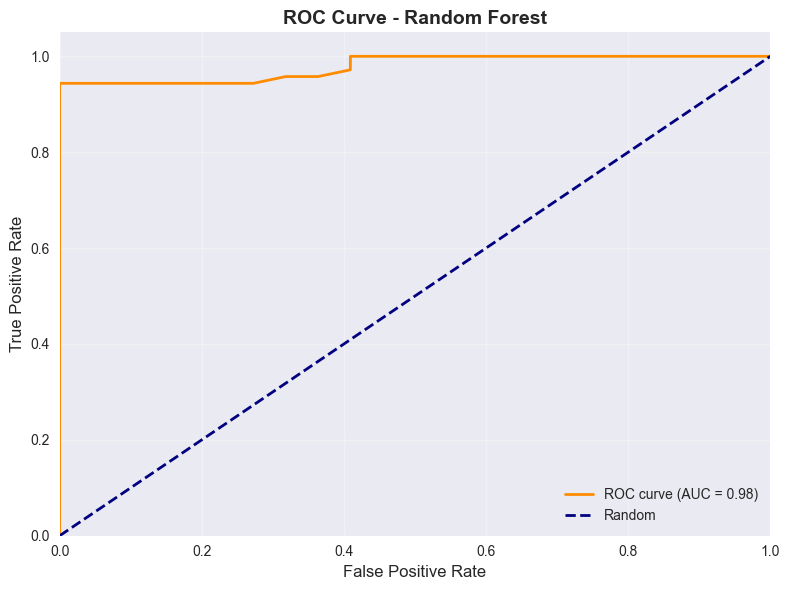

AUC: 0.9789

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89        22
           1       0.99      0.94      0.96        71

    accuracy                           0.95        93
   macro avg       0.91      0.95      0.93        93
weighted avg       0.95      0.95      0.95        93



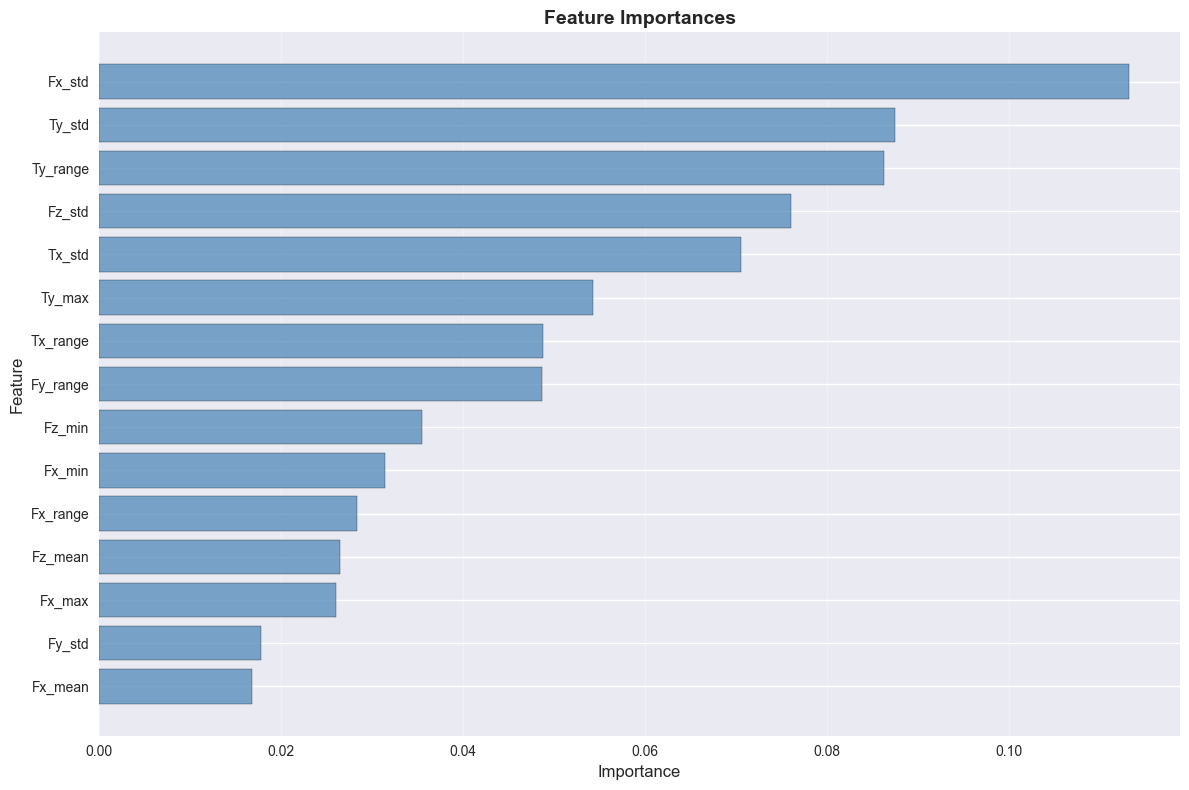


Top 15 Most Important Features:
  Fx_std: 0.1131
  Ty_std: 0.0875
  Ty_range: 0.0863
  Fz_std: 0.0761
  Tx_std: 0.0705
  Ty_max: 0.0543
  Tx_range: 0.0487
  Fy_range: 0.0487
  Fz_min: 0.0354
  Fx_min: 0.0314
  Fx_range: 0.0283
  Fz_mean: 0.0264
  Fx_max: 0.0260
  Fy_std: 0.0178
  Fx_mean: 0.0168


In [5]:
# Entraîner Random Forest
rf_model = supervised_models.train_random_forest(X_train, y_train, cv=5)

# Prédictions
y_pred_rf = supervised_models.predict('random_forest', X_test)
# Pour Random Forest, we can directement utiliser predict_proba (pas de scaler)
y_pred_proba_rf = supervised_models.models['random_forest'].predict_proba(X_test)[:, 1]

# Évaluation
results_rf = evaluate_model(y_test, y_pred_rf, y_pred_proba_rf, 
                           model_name="Random Forest")

# Visualiser les importances de features
plot_feature_importances(rf_model, stat_cols, top_n=15)



### 3.3 support vector machine (svm) with rbf kernel

Reference: Lesson 3 - Support Vector Machines and Kernel Methods

SVM with RBF kernel can learn non-linear decision boundaries. It requires feature scaling for optimal performance. SVM can be computationally expensive for large datasets, so optional sampling is provided.

Hyperparameters:
- C: Regularization strength (inverse of regularization parameter)
- gamma: Kernel coefficient (controls influence of individual samples)
- kernel: Kernel type (RBF for non-linear boundaries)



Training SVM with GridSearchCV...
  - Cross-validation folds: 5
  - Scoring metric: f1_weighted
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  - Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  - Best CV score: 0.9086 ± 0.0194

Results for SVM (RBF)
Accuracy: 0.9247
Precision: 0.9429
Recall: 0.9247
F1-score: 0.9279


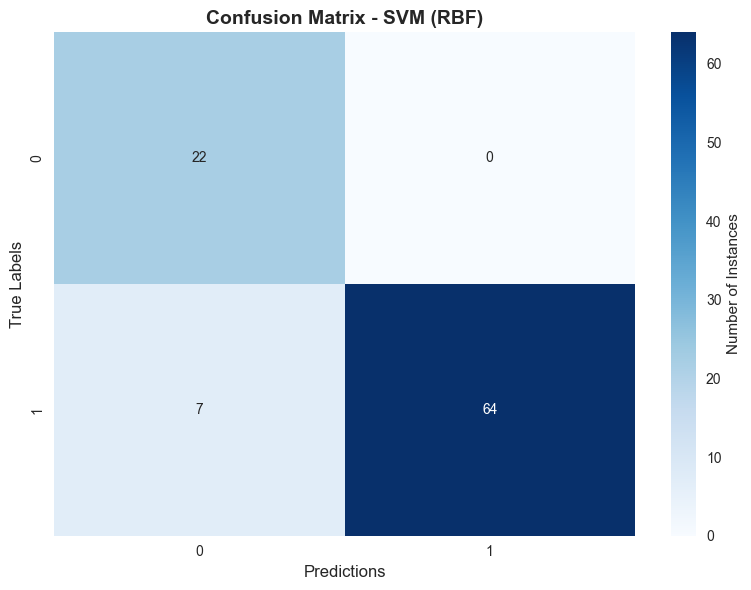

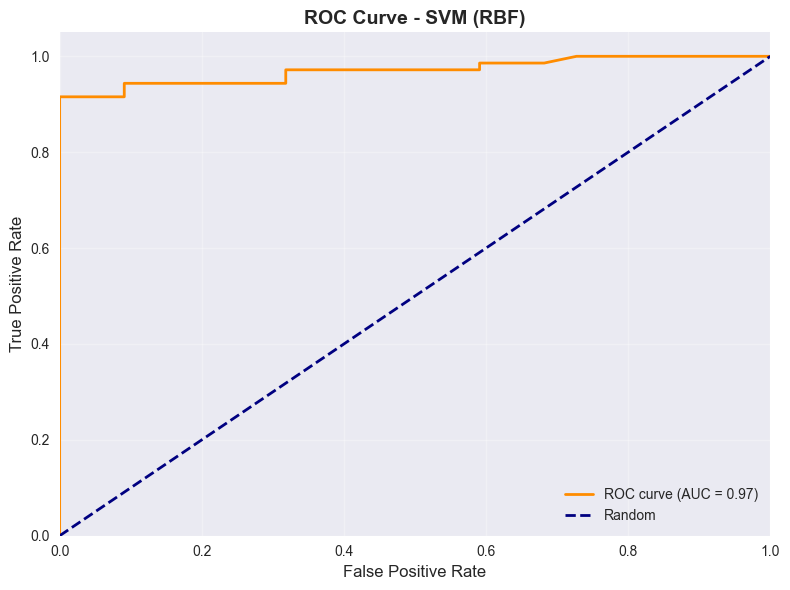

AUC: 0.9702

Classification Report:
              precision    recall  f1-score   support

           0       0.76      1.00      0.86        22
           1       1.00      0.90      0.95        71

    accuracy                           0.92        93
   macro avg       0.88      0.95      0.91        93
weighted avg       0.94      0.92      0.93        93



In [6]:
# Training SVM (can be slow, using a sample if needed)
# SVM requires feature scaling, which is handled automatically by the train_svm method
svm_model = supervised_models.train_svm(X_train, y_train, cv=5, 
                                       sample_size=min(2000, len(X_train)))

# Making predictions (the predict method automatically handles standardization)
# Note: predict_proba already returns the positive class probabilities as a 1D array
y_pred_svm, y_pred_proba_svm = supervised_models.predict('svm', X_test, return_proba=True)
# y_pred_proba_svm is already a 1D array (positive class probabilities), no need to index [:, 1]

# Evaluating the model
results_svm = evaluate_model(y_test, y_pred_svm, y_pred_proba_svm, 
                            model_name="SVM (RBF)")



### 3.4 gradient boosting

Reference: Lesson 3 - Ensemble Methods and Boosting

Gradient Boosting is an ensemble method that builds models sequentially, where each model corrects errors of the previous one. It can achieve high performance but requires careful hyperparameter tuning to avoid overfitting.

Hyperparameters:
- n_estimators: Number of boosting stages
- learning_rate: Step size shrinkage (prevents overfitting)
- max_depth: Maximum depth of trees
- min_samples_split: Minimum samples required to split a node



Training Gradient Boosting with GridSearchCV...
  - Cross-validation folds: 5
  - Scoring metric: f1_weighted
Fitting 5 folds for each of 54 candidates, totalling 270 fits
  - Best parameters: {'learning_rate': 0.2, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}
  - Best CV score: 0.9113 ± 0.0210

Results for Gradient Boosting
Accuracy: 0.9462
Precision: 0.9509
Recall: 0.9462
F1-score: 0.9474


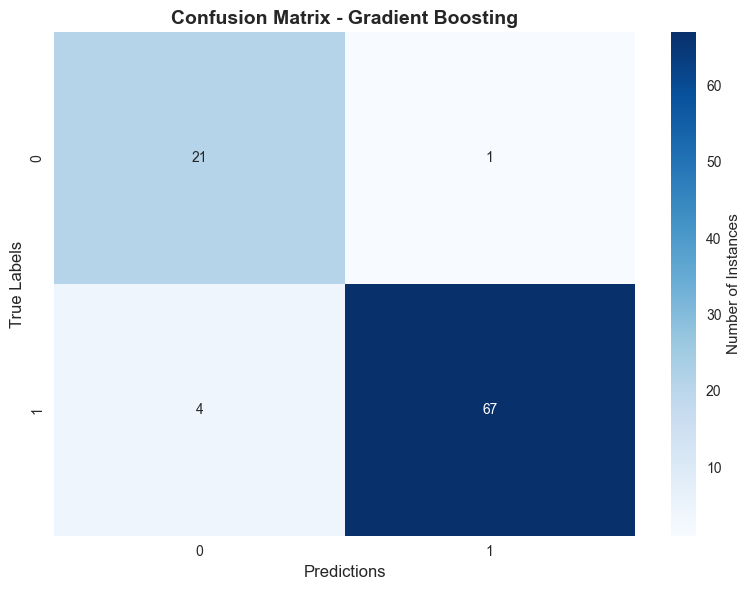

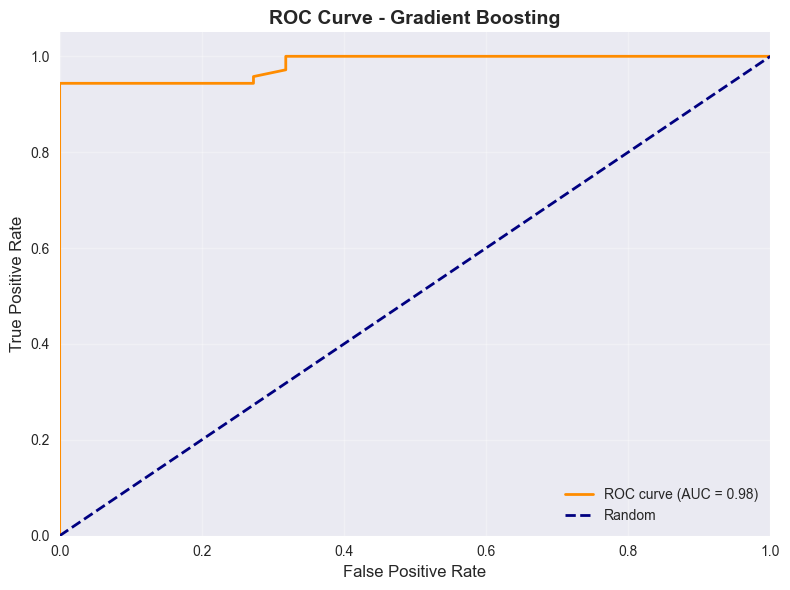

AUC: 0.9830

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89        22
           1       0.99      0.94      0.96        71

    accuracy                           0.95        93
   macro avg       0.91      0.95      0.93        93
weighted avg       0.95      0.95      0.95        93



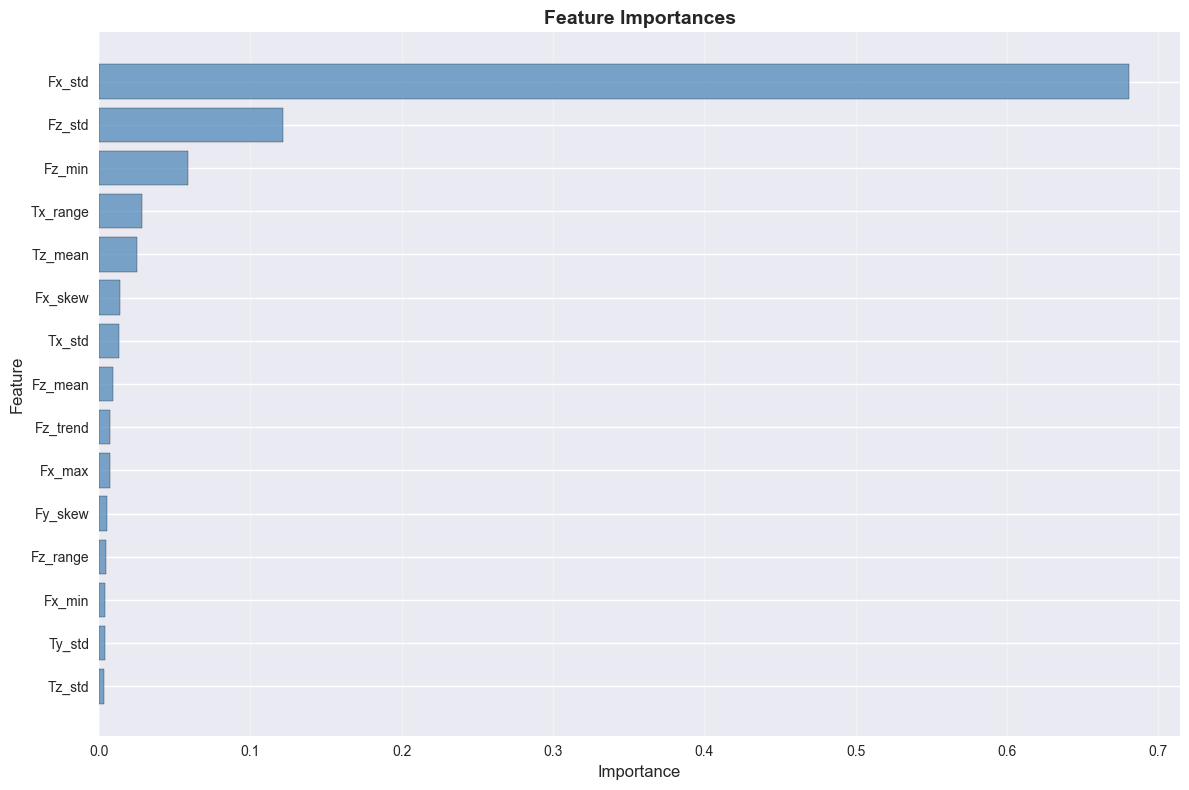


Top 15 Most Important Features:
  Fx_std: 0.6804
  Fz_std: 0.1218
  Fz_min: 0.0585
  Tx_range: 0.0282
  Tz_mean: 0.0250
  Fx_skew: 0.0140
  Tx_std: 0.0132
  Fz_mean: 0.0089
  Fz_trend: 0.0073
  Fx_max: 0.0071
  Fy_skew: 0.0049
  Fz_range: 0.0044
  Fx_min: 0.0041
  Ty_std: 0.0037
  Tz_std: 0.0032


In [7]:
# Entraîner Gradient Boosting
gb_model = supervised_models.train_gradient_boosting(X_train, y_train, cv=5)

# Prédictions
y_pred_gb = supervised_models.predict('gradient_boosting', X_test)
# Pour Gradient Boosting, we can directement utiliser predict_proba (pas de scaler)
y_pred_proba_gb = supervised_models.models['gradient_boosting'].predict_proba(X_test)[:, 1]

# Évaluation
results_gb = evaluate_model(y_test, y_pred_gb, y_pred_proba_gb, 
                           model_name="Gradient Boosting")

# Visualiser les importances de features
plot_feature_importances(gb_model, stat_cols, top_n=15)



## 4. model comparison

Reference: Lesson 4 - Model Comparison and Selection

We compare the performance of all supervised learning models using comprehensive metrics. This comparison helps identify the best model for anomaly detection in industrial robotics.

### Comparison metrics

1. Accuracy: Overall correctness of predictions
2. Precision: Proportion of positive predictions that are correct
3. Recall: Proportion of actual positives correctly identified
4. F1-Score: Harmonic mean of precision and recall
5. AUC: Area under ROC curve (measures model discrimination ability)
6. Cross-Validation: Mean ± std of cross-validation scores (robustness measure)

### Model selection criteria

- Performance: High accuracy, precision, recall, F1-score, AUC
- Robustness: Low standard deviation in cross-validation scores
- Bias-Variance: Good balance between bias and variance
- Interpretability: Ability to interpret model decisions (feature importance)

Academic Note: Model comparison helps identify the best model based we multiple criteria (Lesson 4: Model Selection).



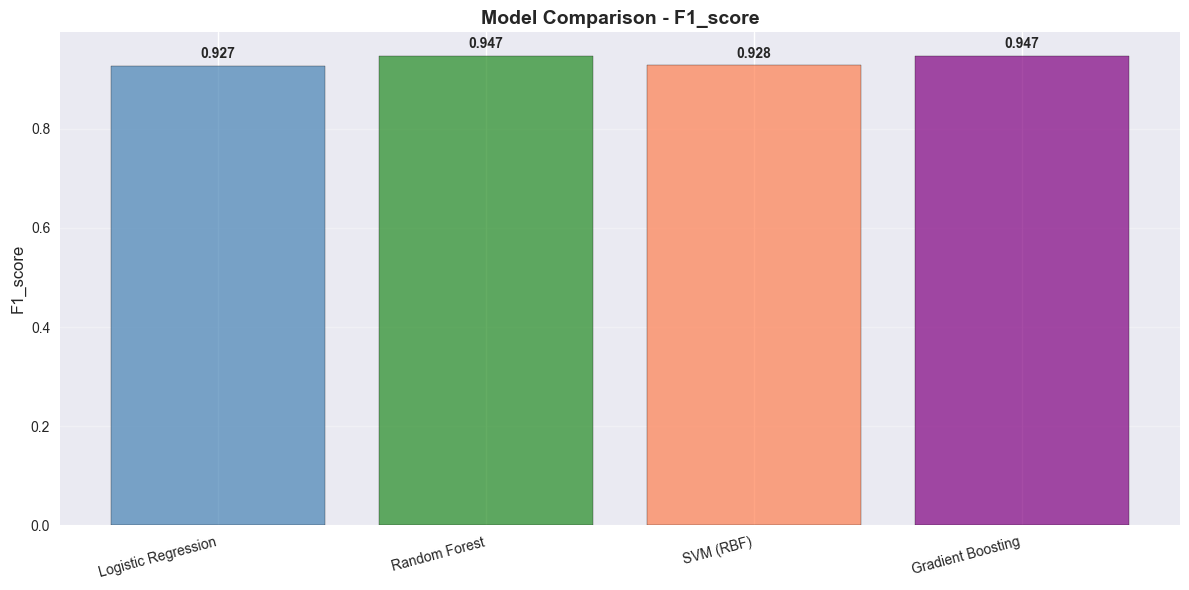


Model Comparison:
                     accuracy precision    recall  f1_score           model_name       auc   cv_mean    cv_std
Logistic Regression  0.924731  0.935864  0.924731  0.927198  Logistic Regression  0.976633  0.912491  0.021857
Random Forest        0.946237  0.950923  0.946237  0.947372        Random Forest  0.978873       NaN       NaN
SVM (RBF)            0.924731    0.9429  0.924731  0.927945            SVM (RBF)   0.97023       NaN       NaN
Gradient Boosting    0.946237  0.950923  0.946237  0.947372    Gradient Boosting  0.983035       NaN       NaN

COMPREHENSIVE MODEL COMPARISON

 Model Performance Comparison:
                     accuracy precision    recall  f1_score           model_name       auc   cv_mean    cv_std
Logistic Regression  0.924731  0.935864  0.924731  0.927198  Logistic Regression  0.976633  0.912491  0.021857
Random Forest        0.946237  0.950923  0.946237  0.947372        Random Forest  0.978873       NaN       NaN
SVM (RBF)            0.924731

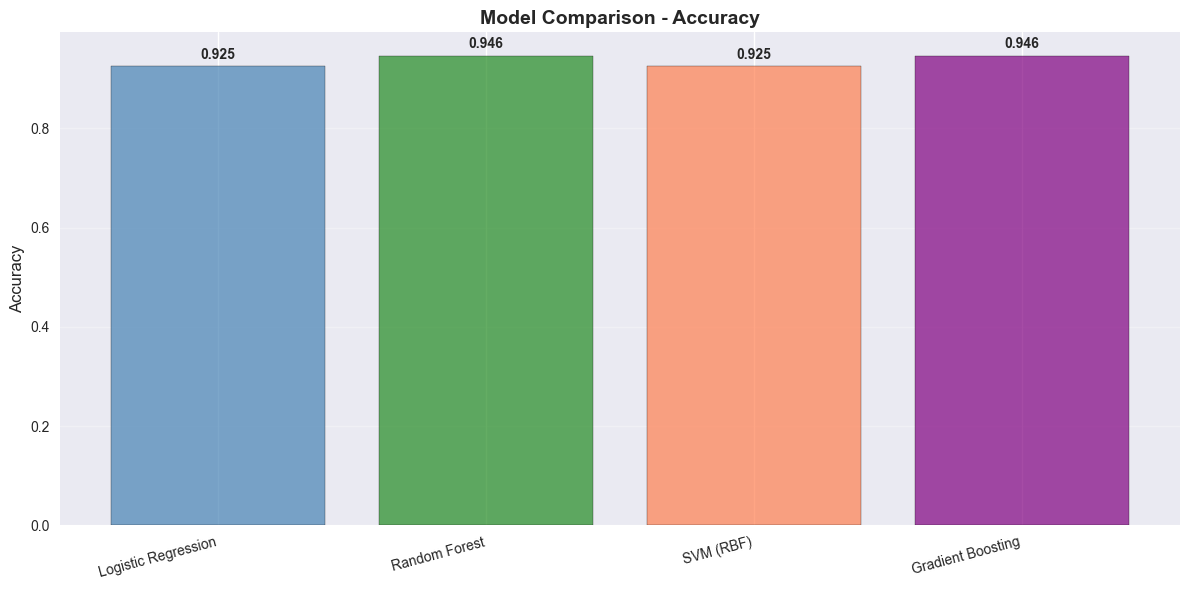


Model Comparison:
                     accuracy precision    recall  f1_score           model_name       auc   cv_mean    cv_std
Logistic Regression  0.924731  0.935864  0.924731  0.927198  Logistic Regression  0.976633  0.912491  0.021857
Random Forest        0.946237  0.950923  0.946237  0.947372        Random Forest  0.978873       NaN       NaN
SVM (RBF)            0.924731    0.9429  0.924731  0.927945            SVM (RBF)   0.97023       NaN       NaN
Gradient Boosting    0.946237  0.950923  0.946237  0.947372    Gradient Boosting  0.983035       NaN       NaN


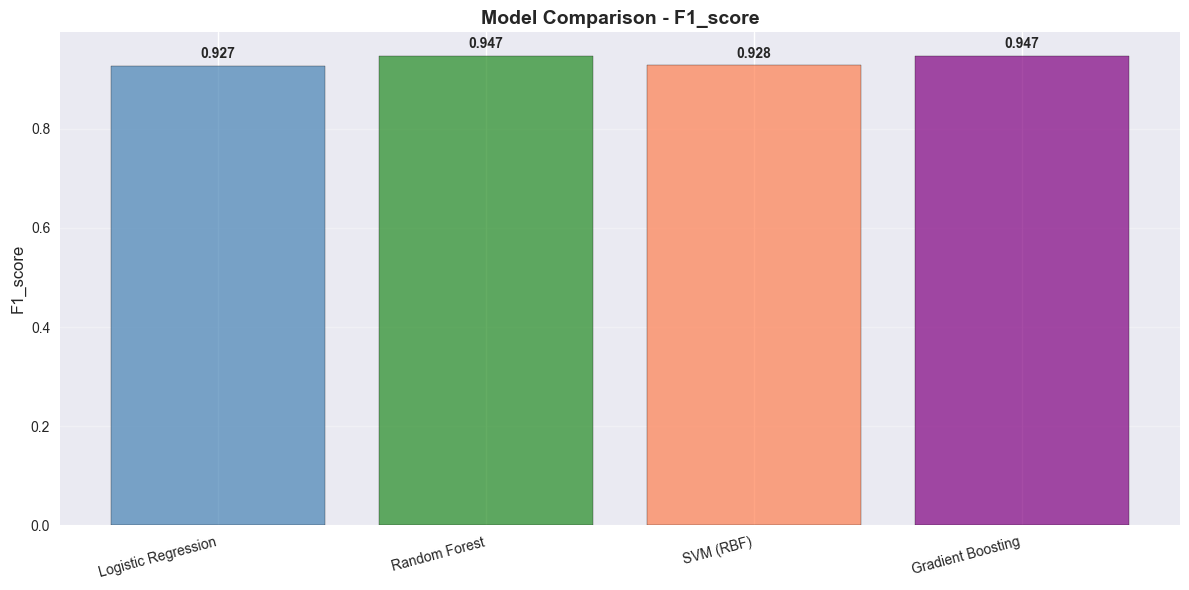


Model Comparison:
                     accuracy precision    recall  f1_score           model_name       auc   cv_mean    cv_std
Logistic Regression  0.924731  0.935864  0.924731  0.927198  Logistic Regression  0.976633  0.912491  0.021857
Random Forest        0.946237  0.950923  0.946237  0.947372        Random Forest  0.978873       NaN       NaN
SVM (RBF)            0.924731    0.9429  0.924731  0.927945            SVM (RBF)   0.97023       NaN       NaN
Gradient Boosting    0.946237  0.950923  0.946237  0.947372    Gradient Boosting  0.983035       NaN       NaN


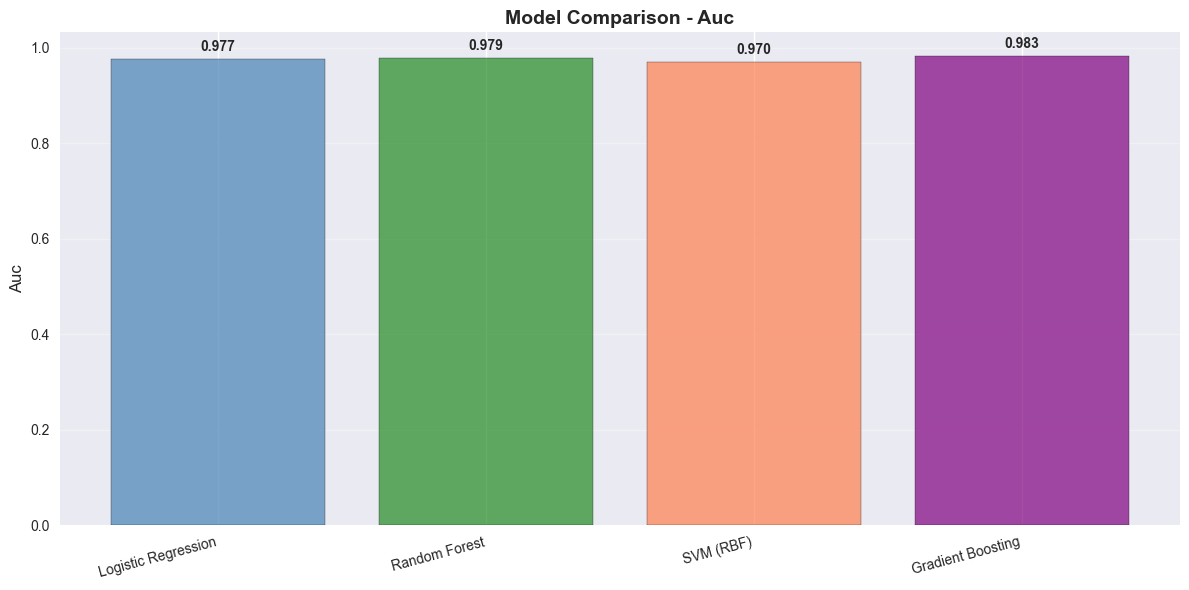


Model Comparison:
                     accuracy precision    recall  f1_score           model_name       auc   cv_mean    cv_std
Logistic Regression  0.924731  0.935864  0.924731  0.927198  Logistic Regression  0.976633  0.912491  0.021857
Random Forest        0.946237  0.950923  0.946237  0.947372        Random Forest  0.978873       NaN       NaN
SVM (RBF)            0.924731    0.9429  0.924731  0.927945            SVM (RBF)   0.97023       NaN       NaN
Gradient Boosting    0.946237  0.950923  0.946237  0.947372    Gradient Boosting  0.983035       NaN       NaN

 Cross-Validation Comparison:
              Model  CV Mean   CV Std
Logistic Regression 0.912491 0.021857
      Random Forest 0.000000 0.000000
          SVM (RBF) 0.000000 0.000000
  Gradient Boosting 0.000000 0.000000

 Best Model (F1-Score): Random Forest
   F1-Score: 0.9474
   Accuracy: 0.9462
   AUC: 0.9789


In [8]:
# Compare all models using comprehensive metrics
# This helps identify the best model for anomaly detection
all_results = {
    'Logistic Regression': results_lr,
    'Random Forest': results_rf,
    'SVM (RBF)': results_svm,
    'Gradient Boosting': results_gb
}

# Create comparison DataFrame
comparison_df = compare_models(all_results, metric='f1_score', figsize=(12, 6))

# Display comprehensive comparison
print("\n" + "="*60)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*60)
print("\n Model Performance Comparison:")
print(comparison_df.to_string())

# Visualize comparison using different metrics
print("\n" + "="*60)
print("VISUALIZATION: MODEL COMPARISON")
print("="*60)

# Accuracy comparison
compare_models(all_results, metric='accuracy', figsize=(12, 6))

# F1-score comparison (handles class imbalance)
compare_models(all_results, metric='f1_score', figsize=(12, 6))

# AUC comparison (if available)
if 'auc' in results_lr:
    compare_models(all_results, metric='auc', figsize=(12, 6))

# Cross-validation comparison
print("\n Cross-Validation Comparison:")
cv_comparison = pd.DataFrame({
    'Model': list(all_results.keys()),
    'CV Mean': [all_results[m].get('cv_mean', 0) for m in all_results.keys()],
    'CV Std': [all_results[m].get('cv_std', 0) for m in all_results.keys()]
})
print(cv_comparison.to_string(index=False))

# Identify best model
best_model = comparison_df['f1_score'].idxmax()
print(f"\n Best Model (F1-Score): {best_model}")
print(f"   F1-Score: {comparison_df.loc[best_model, 'f1_score']:.4f}")
print(f"   Accuracy: {comparison_df.loc[best_model, 'accuracy']:.4f}")
if 'auc' in comparison_df.columns:
    print(f"   AUC: {comparison_df.loc[best_model, 'auc']:.4f}")



## 5. analyse des importances de features

Analysons quels capteurs sont les plus indicatifs d'une défaillance.

### Interprétation physique

- Forces (Fx, Fy, Fz) : Indiquent les collisions et les obstructions
- Couples (Tx, Ty, Tz) : Indiquent les rotations anormales et les défaillances de mouvement
- Statistiques : Mean, std, min, max, skew, kurtosis capturent différents aspects des signaux



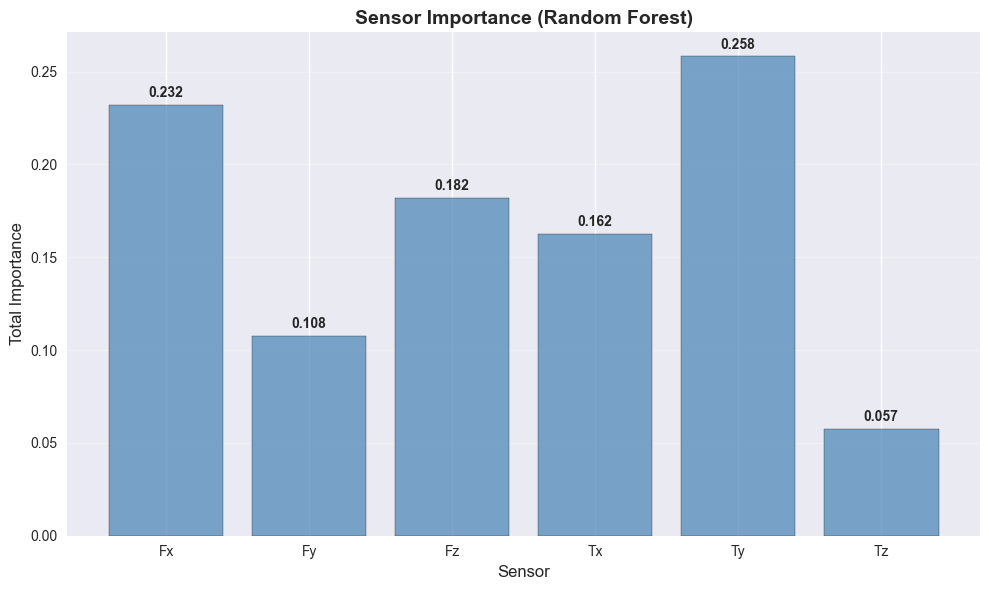


 Sensor Importance Analysis:
  Ty: 0.2582
  Fx: 0.2322
  Fz: 0.1820
  Tx: 0.1625
  Fy: 0.1077
  Tz: 0.0574

 Most Critical Sensors (Top 3):
   Ty: 0.2582
   Fx: 0.2322
   Fz: 0.1820

 Interpretation:
  - Sensors with higher importance are more critical for anomaly detection
  - These sensors should be prioritized in industrial monitoring
  - Feature importance helps optimize sensor placement and monitoring strategies
  - Understanding sensor importance helps interpret model decisions


In [9]:
# Analyser les importances de features par capteur
sensor_names = ['Fx', 'Fy', 'Fz', 'Tx', 'Ty', 'Tz']

# Analyze feature importance for Random Forest
# Random Forest provides feature importance as part of its output
if hasattr(rf_model, 'feature_importances_'):
    importances = rf_model.feature_importances_
    
    # Group by sensor type
    # This helps understand which sensors are most critical for anomaly detection
    sensor_importances = {}
    for sensor in sensor_names:
        sensor_cols = [i for i, col in enumerate(stat_cols) if col.startswith(f'{sensor}_')]
        sensor_importances[sensor] = importances[sensor_cols].sum()
    
    # Visualize sensor importance
    # This helps identify which sensors are most informative
    plt.figure(figsize=(10, 6))
    sensors = list(sensor_importances.keys())
    importances_vals = list(sensor_importances.values())
    plt.bar(sensors, importances_vals, color='steelblue', edgecolor='black', alpha=0.7)
    plt.xlabel('Sensor', fontsize=12)
    plt.ylabel('Total Importance', fontsize=12)
    plt.title('Sensor Importance (Random Forest)', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    
    # Add values we bars
    for i, v in enumerate(importances_vals):
        plt.text(i, v + max(importances_vals) * 0.01, f'{v:.3f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n Sensor Importance Analysis:")
    sorted_sensors = sorted(sensor_importances.items(), key=lambda x: x[1], reverse=True)
    for sensor, imp in sorted_sensors:
        print(f"  {sensor}: {imp:.4f}")
    
    print(f"\n Most Critical Sensors (Top 3):")
    for sensor, imp in sorted_sensors[:3]:
        print(f"   {sensor}: {imp:.4f}")
    
    print("\n Interpretation:")
    print("  - Sensors with higher importance are more critical for anomaly detection")
    print("  - These sensors should be prioritized in industrial monitoring")
    print("  - Feature importance helps optimize sensor placement and monitoring strategies")
    print("  - Understanding sensor importance helps interpret model decisions")



## 6. model saving

Reference: Lesson 4 - Model Persistence and Deployment

We save the best model for future use. Model saving enables:
- Reproducibility: Reuse models without retraining
- Deployment: Deploy models in production systems
- Comparison: Compare models across different experiments

### Model persistence

Models are saved with:
- Model: Trained model instance
- Scaler: StandardScaler (if required)
- Best Parameters: Optimal hyperparameters from GridSearchCV
- Cross-Validation Results: CV scores for model evaluation

Academic Note: Model persistence is essential for production deployment (Lesson 4: Model Deployment).



In [10]:
# Save models for future use
# Models are saved with scalers, best parameters, and cross-validation results
os.makedirs('../models', exist_ok=True)

print("="*60)
print("MODEL SAVING")
print("="*60)

# We utilise GridSearchCV pour optimiser the hyperparameters
# CHOICE : We use GridSearchCV plutôt que de tester manuellement the hyperparameters.
# REASON : This allows us de tester systématiquement toutes les combinaisons d'hyperparamètres et de trouver les meilleures.
# DIFFICULTY : GridSearchCV can be slow to execute, especially for SVM which is computationnellement coûteux.
# SOLUTION : We use la validation croisée (5-fold) to have a robust evaluation without over-optimizing we the test set.
#   we teste plusieurs valeurs for each hyperparamètre, mais pas trop pour éviter un temps d'exécution prohibitif.
# COMPROMISE : We have choisi des grilles de recherche raisonnables - we could tester plus de valeurs, mais cela prendrait des heures.
# Models are saved with scalers, best parameters, and CV results
supervised_models.save_model('random_forest', '../models/random_forest_model.pkl')
supervised_models.save_model('logistic_regression', '../models/logistic_regression_model.pkl')
supervised_models.save_model('svm', '../models/svm_model.pkl')
supervised_models.save_model('gradient_boosting', '../models/gradient_boosting_model.pkl')

# Identify best model based we F1-score
best_model_name = comparison_df['f1_score'].idxmax()
best_model_key = best_model_name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('_kernel', '')
if best_model_key == 'svm_rbf':
    best_model_key = 'svm'

print(f"\n Best Model (F1-Score): {best_model_name}")
print(f"   Model key: {best_model_key}")
print(f"   F1-Score: {comparison_df.loc[best_model_name, 'f1_score']:.4f}")
print(f"   Accuracy: {comparison_df.loc[best_model_name, 'accuracy']:.4f}")
if 'auc' in comparison_df.columns:
    print(f"   AUC: {comparison_df.loc[best_model_name, 'auc']:.4f}")

print("\n All models saved successfully")
print("   Models saved in: ../models/")
print("   Models include: model, scaler, best parameters, CV results")



MODEL SAVING
Model random_forest saved to ../models/random_forest_model.pkl
Model logistic_regression saved to ../models/logistic_regression_model.pkl
Model svm saved to ../models/svm_model.pkl
Model gradient_boosting saved to ../models/gradient_boosting_model.pkl

 Best Model (F1-Score): Random Forest
   Model key: random_forest
   F1-Score: 0.9474
   Accuracy: 0.9462
   AUC: 0.9789

 All models saved successfully
   Models saved in: ../models/
   Models include: model, scaler, best parameters, CV results


## 7. résumé et conclusions

### Résultats des modèles supervisés

1. Logistic Regression : Modèle linéaire simple, rapide mais peut avoir une faible capacité
2. Random Forest : Modèle robuste avec de bonnes performances et interprétabilité
3. SVM (RBF) : Modèle non-linéaire puissant mais peut être lent
4. Gradient Boosting : Modèle puissant avec de bonnes performances

### Insights pour la robotique industrielle

- Capteurs critiques : Certains capteurs sont plus indicatifs que d'autres pour la détection d'anomalies
- Features statistiques : Les statistiques (mean, std, skew) capturent les patterns essentiels
- Performance : Les modèles permettent de détecter les anomalies avec une bonne précision
- Interprétabilité : Les importances de features révèlent quels capteurs surveiller

### Prochaines étapes

Dans le notebook suivant, we will:
- Entraîner des modèles non supervisés (Isolation Forest, One-Class SVM)
- Comparer les approches supervisées vs non supervisées
- Visualiser les anomalies détectées en PCA




In [11]:
print(" Notebook 3 terminé!")
print("\nModèles supervisés entraînés et évalués:")
print(f"  - Logistic Regression: Accuracy={results_lr['accuracy']:.4f}, F1={results_lr['f1_score']:.4f}")
print(f"  - Random Forest: Accuracy={results_rf['accuracy']:.4f}, F1={results_rf['f1_score']:.4f}")
print(f"  - SVM (RBF): Accuracy={results_svm['accuracy']:.4f}, F1={results_svm['f1_score']:.4f}")
print(f"  - Gradient Boosting: Accuracy={results_gb['accuracy']:.4f}, F1={results_gb['f1_score']:.4f}")



 Notebook 3 terminé!

Modèles supervisés entraînés et évalués:
  - Logistic Regression: Accuracy=0.9247, F1=0.9272
  - Random Forest: Accuracy=0.9462, F1=0.9474
  - SVM (RBF): Accuracy=0.9247, F1=0.9279
  - Gradient Boosting: Accuracy=0.9462, F1=0.9474
